# TP2 — Influencia de las estrategias de muestreo
## Caso de estudio: Reconstrucción del campo de flujo en una cavidad cuadrada

**Redes Neuronales Informadas por Física** — Especialización en Inteligencia Artificial (CEIA-FIUBA)
3er bimestre 2026

**Nombre:** Julia Stephania Maldonado Gomez

---

### Supuestos adoptados (además de los ya documentados en el TP1)

Este TP2 reutiliza el modelo PINN *vanilla* desarrollado en el TP1 (misma arquitectura, mismas ecuaciones
de gobierno — Navier-Stokes incompresible 2D estacionario, $Re=100$ — mismo dominio $[0,1]^2$ y mismas
condiciones de borde de *lid-driven cavity*). Se documentan a continuación los supuestos adicionales
específicos de este TP2:

1. **Condición de referencia de presión.** El enunciado menciona explícitamente una *"condición de
   referencia de presión, evaluada en un único punto fijo"* que no participa de la métrica de RAR-D, y pesa
   esta condición con $\lambda_p=100$ dentro de la función de pérdida. En el TP1 la indeterminación de
   *gauge* de presión se resolvía únicamente **a posteriori** (corrección de nivel medio contra el
   ground-truth, solo para evaluación). Acá, en cambio, se incorpora **durante el entrenamiento** un término
   de pérdida adicional que fija el valor de $p$ en un único punto interior fijo del dominio,
   $(x_{ref}, y_{ref}) = (0.5,\ 0.5)$, a un valor de referencia arbitrario $p_{ref}=0$ (no se usa ningún dato
   rotulado ni del ground-truth para fijar este valor, tal como exige el enunciado). Esto resuelve la
   indeterminación de *gauge* dentro del propio esquema de optimización, en vez de dejarla completamente
   libre. La corrección de nivel contra el ground-truth (igual que en el TP1) se sigue aplicando **solo al
   momento de evaluar** el error de norma-2, nunca durante el entrenamiento.

2. **Discrepancia numérica en el esquema RAR-D.** El enunciado indica: *"entrenar 4 rondas de 10.000 épocas
   cada una, agregando en cada ronda 1.000 puntos... la ronda final llegará a 10.000 puntos de colocación"*.
   Matemáticamente $5.000 + 4\times1.000 = 9.000 \neq 10.000$. Se decidió, mientras se consulta a la cátedra,
   **seguir literalmente lo escrito** (1.000 puntos agregados por ronda, 4 rondas), por lo que el esquema
   RAR-D en este notebook **termina con 9.000 puntos de colocación** en la ronda final (en vez de 10.000).
   Esto se deja documentado explícitamente porque afecta la comparación "en igualdad de condiciones" con el
   baseline (que sí usa $N_{pde}=10.000$ puntos fijos). Si la cátedra confirma que corresponde llegar a
   10.000, alcanza con cambiar `N_ADD_PER_ROUND` de 1.000 a 1.250 en la sección 2 más abajo.

3. **Arquitectura y optimizador.** Para que la comparación entre estrategias de muestreo sea "justa" (como
   pide el enunciado), se reutiliza exactamente la misma arquitectura, optimizador y ponderación interna de
   pérdidas que en el TP1 ($[2,40,40,40,40,40,3]$, tanh, Xavier, Adam lr=1e-3, weight_decay=1e-5), y además
   se **reinicializan los pesos de la red con la misma semilla** antes de cada una de las 4 corridas
   (baseline + A + B + C), para que las diferencias de desempeño se deban únicamente a la estrategia de
   muestreo y no a una inicialización distinta.

4. **Puntos de borde ($\Omega_{bc}$).** El enunciado no especifica la estrategia de muestreo de los puntos de
   borde para el baseline (solo dice "estrategia de LHS" en general, refiriéndose al muestreo de colocación
   interior). Se mantiene el mismo esquema del TP1 (muestreo aleatorio uniforme repartido en las 4 paredes),
   y se generan **una única vez con semilla fija**, reutilizándose idénticos en las 4 corridas — así también
   se aísla el efecto de la estrategia de muestreo interior, que es lo que este TP2 busca comparar.


## 0. Setup e importación de librerías

In [1]:
import numpy as np
import torch
import torch.nn as nn
import scipy.io as sio
from scipy.stats import qmc
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import pandas as pd
import time

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

plt.rcParams['figure.dpi'] = 100


Device: cuda
GPU: Tesla T4


### 0.1 Carga del dataset ground-truth

Idéntico al TP1: se cargan `velocity.mat` (contiene $x,y,z,u,v,w$) y `pressure.mat` (contiene $x,y,z,p$).

In [2]:
data_v = sio.loadmat('velocity.mat')
data_p = sio.loadmat('pressure.mat')

x_gt = data_v['x'].flatten()
y_gt = data_v['y'].flatten()
u_gt = data_v['u'].flatten()
v_gt = data_v['v'].flatten()
p_gt = data_p['p'].flatten()

coords_match = np.allclose(x_gt, data_p['x'].flatten()) and np.allclose(y_gt, data_p['y'].flatten())
assert coords_match, "Las coordenadas de velocity.mat y pressure.mat no coinciden"

N_gt = len(x_gt)
print(f'Puntos ground-truth: {N_gt}')
print(f'Dominio: x in [{x_gt.min():.2f}, {x_gt.max():.2f}], y in [{y_gt.min():.2f}, {y_gt.max():.2f}]')

gt_tree = cKDTree(np.column_stack([x_gt, y_gt]))


Puntos ground-truth: 20201
Dominio: x in [0.00, 1.00], y in [0.00, 1.00]


## 1. Componentes reutilizados y nuevos del pipeline

### 1.1 Arquitectura de la red y residuos de la PDE (idénticos al TP1)

Se reutiliza exactamente la misma red ($[2,40,40,40,40,40,3]$, tanh, Xavier) y la misma función de residuos
de Navier-Stokes incompresible 2D estacionario con $Re=100$ desarrolladas en el TP1.

In [3]:
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        modules = []
        for i in range(len(layers) - 2):
            linear = nn.Linear(layers[i], layers[i + 1])
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            modules.append(linear)
            modules.append(nn.Tanh())
        linear_out = nn.Linear(layers[-2], layers[-1])
        nn.init.xavier_normal_(linear_out.weight)
        nn.init.zeros_(linear_out.bias)
        modules.append(linear_out)
        self.net = nn.Sequential(*modules)

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        out = self.net(inp)
        u = out[:, 0:1]
        v = out[:, 1:2]
        p = out[:, 2:3]
        return u, v, p


LAYERS = [2, 40, 40, 40, 40, 40, 3]
Re = 100.0


def pde_residuals(model, x, y, Re=Re):
    u, v, p = model(x, y)

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, grad_outputs=torch.ones_like(p), create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, grad_outputs=torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, grad_outputs=torch.ones_like(v_y), create_graph=True)[0]

    r_u = u * u_x + v * u_y + p_x - (1.0 / Re) * (u_xx + u_yy)
    r_v = u * v_x + v * v_y + p_y - (1.0 / Re) * (v_xx + v_yy)
    r_cont = u_x + v_y
    return r_u, r_v, r_cont


def make_model(seed=SEED):
    # Reinicializa la semilla antes de crear la red para que todas las corridas
    # (baseline y las 3 configuraciones RAR-D) partan de los mismos pesos iniciales.
    torch.manual_seed(seed)
    model = PINN(LAYERS).to(device)
    return model


### 1.2 Condición de referencia de presión

Punto fijo interior $(0.5,\,0.5)$, valor de referencia arbitrario $p_{ref}=0$ (ver supuesto 1 documentado
arriba). Esta condición se pondera con $\lambda_p=100$ y se agrega como un tercer término a la función de
pérdida, evaluado en un único punto (por eso no participa de la métrica de residuo puntual de RAR-D).

In [4]:
x_ref_t = torch.tensor([[0.5]], dtype=torch.float32, requires_grad=True, device=device)
y_ref_t = torch.tensor([[0.5]], dtype=torch.float32, requires_grad=True, device=device)
p_ref_t = torch.tensor([[0.0]], dtype=torch.float32, device=device)


### 1.3 Funciones de muestreo: LHS (colocación interior) y paredes (condición de borde)

El baseline y la inicialización de RAR-D usan **Latin Hypercube Sampling** para $\Omega_{pde}$ (a diferencia
del TP1, que usaba muestreo aleatorio uniforme simple). Los puntos de borde se siguen muestreando igual que
en el TP1: aleatorios uniformes repartidos en las 4 paredes.

In [5]:
def lhs_sample(n, seed=None, eps=1e-4):
    # Muestreo LHS en el interior estricto del dominio (0,1)x(0,1), excluyendo
    # las fronteras por la misma razón discutida en el TP1 (punto 1.4).
    sampler = qmc.LatinHypercube(d=2, seed=seed)
    sample = sampler.random(n=n)
    sample = eps + sample * (1 - 2 * eps)
    x = sample[:, 0:1].astype(np.float32)
    y = sample[:, 1:2].astype(np.float32)
    return x, y


def make_bc_points(n_bc, seed=None):
    rng = np.random.default_rng(seed)
    n_wall = n_bc // 4

    x_top = rng.uniform(0, 1, size=(n_wall, 1)); y_top = np.ones((n_wall, 1))
    u_top = np.ones((n_wall, 1)); v_top = np.zeros((n_wall, 1))

    x_bot = rng.uniform(0, 1, size=(n_wall, 1)); y_bot = np.zeros((n_wall, 1))
    u_bot = np.zeros((n_wall, 1)); v_bot = np.zeros((n_wall, 1))

    x_left = np.zeros((n_wall, 1)); y_left = rng.uniform(0, 1, size=(n_wall, 1))
    u_left = np.zeros((n_wall, 1)); v_left = np.zeros((n_wall, 1))

    x_right = np.ones((n_wall, 1)); y_right = rng.uniform(0, 1, size=(n_wall, 1))
    u_right = np.zeros((n_wall, 1)); v_right = np.zeros((n_wall, 1))

    x_bc = np.vstack([x_top, x_bot, x_left, x_right]).astype(np.float32)
    y_bc = np.vstack([y_top, y_bot, y_left, y_right]).astype(np.float32)
    u_bc = np.vstack([u_top, u_bot, u_left, u_right]).astype(np.float32)
    v_bc = np.vstack([v_top, v_bot, v_left, v_right]).astype(np.float32)
    return x_bc, y_bc, u_bc, v_bc


# Puntos de borde: se generan UNA sola vez y se reutilizan idénticos en las 4 corridas
N_BC = 1000
x_bc_np, y_bc_np, u_bc_np, v_bc_np = make_bc_points(N_BC, seed=SEED)
x_bc_t = torch.tensor(x_bc_np, device=device)
y_bc_t = torch.tensor(y_bc_np, device=device)
u_bc_t = torch.tensor(u_bc_np, device=device)
v_bc_t = torch.tensor(v_bc_np, device=device)
print(f'Puntos de borde (fijos, reutilizados en las 4 corridas): {x_bc_t.shape[0]}')


Puntos de borde (fijos, reutilizados en las 4 corridas): 1000


### 1.4 Ponderaciones de la función de pérdida y *schedule* de la tasa de aprendizaje

$\lambda_{bc}=10$, $\lambda_p=100$ (dados por el enunciado). El peso interno de la PDE se deja en 1, igual
que en el TP1 ($w_{pde}=1$, $w_{bc}=10$ en TP1 $\to$ acá $\lambda_{bc}=10$ coincide).

Como acá se entrena durante 50.000 épocas en vez de las 8.000 del TP1, se recalcula el factor `gamma` del
decaimiento exponencial de la tasa de aprendizaje para que el **decaimiento total acumulado** sea el mismo
que en el TP1 (mismo criterio de estabilización, adaptado a la duración de este entrenamiento).

In [6]:
W_BC = 10.0
W_P = 100.0

GAMMA_TP1 = 0.9997
EPOCHS_TP1 = 8000
EPOCHS_TOTAL = 50000   # mismo total de épocas para baseline y para cada corrida RAR-D (10k + 4x10k)

GAMMA = GAMMA_TP1 ** (EPOCHS_TP1 / EPOCHS_TOTAL)
print(f'Gamma TP1 (referencia): {GAMMA_TP1}  ->  decaimiento total en {EPOCHS_TP1} epochs: {GAMMA_TP1**EPOCHS_TP1:.4f}')
print(f'Gamma recalculado para {EPOCHS_TOTAL} epochs: {GAMMA:.8f}  ->  decaimiento total: {GAMMA**EPOCHS_TOTAL:.4f}')


Gamma TP1 (referencia): 0.9997  ->  decaimiento total en 8000 epochs: 0.0907
Gamma recalculado para 50000 epochs: 0.99995199  ->  decaimiento total: 0.0907


### 1.5 Función de entrenamiento genérica

Soporta tanto el baseline (un único bloque de 50.000 épocas) como RAR-D (varios bloques consecutivos que
reutilizan el mismo modelo/optimizador/scheduler, pero con el conjunto de puntos de colocación
$\Omega_{pde}$ actualizado entre bloques).

In [7]:
def train_block(model, optimizer, scheduler, x_pde_t, y_pde_t, epochs, history,
                 log_every=2000, Re=Re, tag=''):
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        r_u, r_v, r_cont = pde_residuals(model, x_pde_t, y_pde_t, Re=Re)
        loss_mom_u = (r_u ** 2).mean()
        loss_mom_v = (r_v ** 2).mean()
        loss_cont = (r_cont ** 2).mean()
        loss_pde = loss_mom_u + loss_mom_v + loss_cont

        u_pred_bc, v_pred_bc, _ = model(x_bc_t, y_bc_t)
        loss_bc = ((u_pred_bc - u_bc_t) ** 2).mean() + ((v_pred_bc - v_bc_t) ** 2).mean()

        _, _, p_pred_ref = model(x_ref_t, y_ref_t)
        loss_p = ((p_pred_ref - p_ref_t) ** 2).mean()

        loss = loss_pde + W_BC * loss_bc + W_P * loss_p

        loss.backward()
        optimizer.step()
        scheduler.step()

        history['total'].append(loss.item())
        history['pde'].append(loss_pde.item())
        history['bc'].append(loss_bc.item())
        history['p_ref'].append(loss_p.item())

        if epoch % log_every == 0 or epoch == 1:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  [{tag}] epoch {epoch:5d}/{epochs} | loss_total={loss.item():.4e} | '
                  f'loss_pde={loss_pde.item():.4e} | loss_bc={loss_bc.item():.4e} | '
                  f'loss_p_ref={loss_p.item():.4e} | lr={lr_now:.2e}')

    return history


### 1.6 Métrica de residuo puntual y selección adaptativa RAR-D

$\varepsilon(\mathbf{x}) = \sqrt{r_u(\mathbf{x})^2 + r_v(\mathbf{x})^2 + r_c(\mathbf{x})^2}$ (la condición de
referencia de presión **no** participa, tal como indica el enunciado).

$p(\mathbf{x}) \propto \dfrac{\varepsilon^k(\mathbf{x})}{\mathbb{E}[\varepsilon^k(\mathbf{x})]} + c$

Los puntos se seleccionan **sin reemplazo** del pool de candidatos, que se va reduciendo ronda a ronda (una
vez que un punto candidato se selecciona, se retira del pool para las rondas siguientes).

In [8]:
def compute_epsilon(model, x_np, y_np, Re=Re):
    x_t = torch.tensor(x_np, requires_grad=True, device=device)
    y_t = torch.tensor(y_np, requires_grad=True, device=device)
    r_u, r_v, r_c = pde_residuals(model, x_t, y_t, Re=Re)
    eps = torch.sqrt(r_u ** 2 + r_v ** 2 + r_c ** 2)
    return eps.detach().cpu().numpy().flatten()


def rad_select(model, pool_x, pool_y, n_add, k, c, Re=Re):
    eps = compute_epsilon(model, pool_x, pool_y, Re=Re)
    eps_k = eps ** k
    prob = eps_k / eps_k.mean() + c
    prob = prob / prob.sum()

    idx = np.random.choice(len(pool_x), size=n_add, replace=False, p=prob)
    new_x, new_y = pool_x[idx], pool_y[idx]

    mask = np.ones(len(pool_x), dtype=bool)
    mask[idx] = False
    pool_x_remaining = pool_x[mask]
    pool_y_remaining = pool_y[mask]
    return new_x, new_y, pool_x_remaining, pool_y_remaining


## 2. Funciones que arman cada corrida (baseline y RAR-D)

`N_ADD_PER_ROUND = 1000` sigue lo escrito literalmente en el enunciado (ver supuesto 2 documentado al
inicio). Cambiar a `1250` si la cátedra confirma que la ronda final debe llegar a 10.000 puntos.

In [9]:
N_PDE_BASELINE = 10000
EPOCHS_BASELINE = 50000

N_INIT_RAD = 5000
S0_SIZE = 20000
N_ROUNDS = 4
N_ADD_PER_ROUND = 1000       # ver supuesto 2 (discrepancia del enunciado)
EPOCHS_PER_BLOCK = 10000
LOG_EVERY = 2000


def run_baseline(seed=SEED):
    print('=== BASELINE (LHS) ===')
    x_pde_np, y_pde_np = lhs_sample(N_PDE_BASELINE, seed=seed)
    x_pde_t = torch.tensor(x_pde_np, requires_grad=True, device=device)
    y_pde_t = torch.tensor(y_pde_np, requires_grad=True, device=device)

    model = make_model(seed=seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=GAMMA)
    history = {'total': [], 'pde': [], 'bc': [], 'p_ref': []}

    t0 = time.time()
    train_block(model, optimizer, scheduler, x_pde_t, y_pde_t, EPOCHS_BASELINE,
                history, log_every=LOG_EVERY, tag='baseline')
    train_time = time.time() - t0
    print(f'Baseline finalizado en {train_time:.1f}s ({train_time/60:.1f} min)\n')

    return {
        'name': 'Baseline (LHS)', 'model': model, 'history': history,
        'train_time': train_time, 'x_pde_final': x_pde_np, 'y_pde_final': y_pde_np,
        'n_pde_final': N_PDE_BASELINE, 'rounds_info': None,
    }


def run_rad(config_name, k, c, seed=SEED):
    print(f'=== RAR-D — Configuración {config_name} (k={k}, c={c}) ===')
    x_pde_np, y_pde_np = lhs_sample(N_INIT_RAD, seed=seed)
    x_pool, y_pool = lhs_sample(S0_SIZE, seed=seed + 1000)  # pool de candidatos, semilla distinta

    model = make_model(seed=seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=GAMMA)
    history = {'total': [], 'pde': [], 'bc': [], 'p_ref': []}
    rounds_info = [{'round': 0, 'n_pde': len(x_pde_np), 'pool_remaining': len(x_pool)}]

    t0 = time.time()

    x_pde_t = torch.tensor(x_pde_np, requires_grad=True, device=device)
    y_pde_t = torch.tensor(y_pde_np, requires_grad=True, device=device)
    train_block(model, optimizer, scheduler, x_pde_t, y_pde_t, EPOCHS_PER_BLOCK,
                history, log_every=LOG_EVERY, tag=f'{config_name} init')

    for r in range(1, N_ROUNDS + 1):
        new_x, new_y, x_pool, y_pool = rad_select(model, x_pool, y_pool, N_ADD_PER_ROUND, k, c)
        x_pde_np = np.vstack([x_pde_np, new_x])
        y_pde_np = np.vstack([y_pde_np, new_y])
        rounds_info.append({'round': r, 'n_pde': len(x_pde_np), 'pool_remaining': len(x_pool)})

        x_pde_t = torch.tensor(x_pde_np, requires_grad=True, device=device)
        y_pde_t = torch.tensor(y_pde_np, requires_grad=True, device=device)
        train_block(model, optimizer, scheduler, x_pde_t, y_pde_t, EPOCHS_PER_BLOCK,
                    history, log_every=LOG_EVERY, tag=f'{config_name} ronda {r}')

    train_time = time.time() - t0
    print(f'RAR-D {config_name} finalizado en {train_time:.1f}s ({train_time/60:.1f} min) '
          f'| N_pde final = {len(x_pde_np)}\n')

    return {
        'name': f'RAR-D {config_name} (k={k}, c={c})', 'model': model, 'history': history,
        'train_time': train_time, 'x_pde_final': x_pde_np, 'y_pde_final': y_pde_np,
        'n_pde_final': len(x_pde_np), 'rounds_info': rounds_info,
    }


## 3. Ejecución de las 4 corridas

**Atención:** esto es lo que tarda horas en CPU y ~30-60 minutos en GPU T4 de Colab (ver instrucciones que
te pasé antes). Verificá que `Device: cuda` haya aparecido en la celda de setup antes de correr esto.

In [10]:
results = {}
results['baseline'] = run_baseline()
results['A'] = run_rad('A', k=1, c=1)
results['B'] = run_rad('B', k=2, c=0)
results['C'] = run_rad('C', k=1, c=3)

print('Las 4 corridas terminaron.')
for key, res in results.items():
    print(f"  {res['name']:28s} | tiempo={res['train_time']/60:6.1f} min | N_pde_final={res['n_pde_final']}")


=== BASELINE (LHS) ===
  [baseline] epoch     1/50000 | loss_total=4.6931e+00 | loss_pde=6.2801e-02 | loss_bc=4.5868e-01 | loss_p_ref=4.3428e-04 | lr=1.00e-03
  [baseline] epoch  2000/50000 | loss_total=1.2593e-01 | loss_pde=1.8487e-02 | loss_bc=1.0744e-02 | loss_p_ref=3.0381e-10 | lr=9.08e-04
  [baseline] epoch  4000/50000 | loss_total=9.4416e-02 | loss_pde=1.7433e-02 | loss_bc=7.0522e-03 | loss_p_ref=6.4612e-05 | lr=8.25e-04
  [baseline] epoch  6000/50000 | loss_total=6.3189e-02 | loss_pde=1.4448e-02 | loss_bc=4.4376e-03 | loss_p_ref=4.3659e-05 | lr=7.50e-04
  [baseline] epoch  8000/50000 | loss_total=3.0333e-02 | loss_pde=6.3959e-03 | loss_bc=2.3937e-03 | loss_p_ref=6.8098e-10 | lr=6.81e-04
  [baseline] epoch 10000/50000 | loss_total=1.1740e-02 | loss_pde=3.4534e-03 | loss_bc=8.2608e-04 | loss_p_ref=2.5422e-07 | lr=6.19e-04
  [baseline] epoch 12000/50000 | loss_total=9.3586e-03 | loss_pde=2.6276e-03 | loss_bc=5.9064e-04 | loss_p_ref=8.2464e-06 | lr=5.62e-04
  [baseline] epoch 14000/

## 4. Validación de los modelos

### 4.1 Predicción sobre la grilla ground-truth + corrección de *gauge* de presión

Igual metodología que en el TP1 (punto 3.1): se evalúa cada modelo sobre las coordenadas del ground-truth y
se calibra un offset constante de presión que minimiza $\|\hat p + c - p\|_2$, **solo a fines de
evaluación** (nunca se usó el ground-truth durante el entrenamiento).

In [11]:
def norm2_error(pred, true):
    abs_err = np.linalg.norm(pred - true, ord=2)
    rel_err = abs_err / np.linalg.norm(true, ord=2)
    return abs_err, rel_err


def evaluate_model(model):
    model.eval()
    x_eval = torch.tensor(x_gt.reshape(-1, 1).astype(np.float32), device=device)
    y_eval = torch.tensor(y_gt.reshape(-1, 1).astype(np.float32), device=device)
    with torch.no_grad():
        u_pred, v_pred, p_pred = model(x_eval, y_eval)
    u_pred = u_pred.cpu().numpy().flatten()
    v_pred = v_pred.cpu().numpy().flatten()
    p_pred = p_pred.cpu().numpy().flatten()

    p_offset = np.mean(p_gt - p_pred)
    p_pred_corrected = p_pred + p_offset

    err_u_abs, err_u_rel = norm2_error(u_pred, u_gt)
    err_v_abs, err_v_rel = norm2_error(v_pred, v_gt)
    err_p_abs, err_p_rel = norm2_error(p_pred_corrected, p_gt)

    return {
        'u_pred': u_pred, 'v_pred': v_pred, 'p_pred': p_pred_corrected, 'p_offset': p_offset,
        'err_u_rel': err_u_rel, 'err_v_rel': err_v_rel, 'err_p_rel': err_p_rel,
        'err_u_abs': err_u_abs, 'err_v_abs': err_v_abs, 'err_p_abs': err_p_abs,
    }


for key, res in results.items():
    res['eval'] = evaluate_model(res['model'])
    ev = res['eval']
    print(f"{res['name']:28s} | err_u={ev['err_u_rel']*100:6.2f}% | "
          f"err_v={ev['err_v_rel']*100:6.2f}% | err_p={ev['err_p_rel']*100:6.2f}%")


Baseline (LHS)               | err_u=  6.32% | err_v=  9.74% | err_p= 40.87%
RAR-D A (k=1, c=1)           | err_u=  7.36% | err_v= 10.33% | err_p= 30.67%
RAR-D B (k=2, c=0)           | err_u=  7.63% | err_v= 10.91% | err_p= 30.98%
RAR-D C (k=1, c=3)           | err_u=  7.11% | err_v= 10.12% | err_p= 30.96%


### 4.2 Tabla comparativa final

In [12]:
rows = []
for key, res in results.items():
    ev = res['eval']
    rows.append({
        'Configuración': res['name'],
        'N_pde final': res['n_pde_final'],
        'Épocas totales': EPOCHS_TOTAL,
        'Tiempo entren. (min)': round(res['train_time'] / 60, 2),
        'Error rel. u (%)': round(ev['err_u_rel'] * 100, 3),
        'Error rel. v (%)': round(ev['err_v_rel'] * 100, 3),
        'Error rel. p (%)': round(ev['err_p_rel'] * 100, 3),
    })

df_summary = pd.DataFrame(rows)
df_summary.to_csv('tp2_resultados_resumen.csv', index=False)
df_summary


,Configuración,N_pde final,Épocas totales,Tiempo entren. (min),Error rel. u (%),Error rel. v (%),Error rel. p (%)
0,Baseline (LHS),10000,50000,23.73,6.319,9.742,40.868
1,"RAR-D A (k=1, c=1)",9000,50000,23.62,7.355,10.332,30.675
2,"RAR-D B (k=2, c=0)",9000,50000,23.92,7.633,10.907,30.977
3,"RAR-D C (k=1, c=3)",9000,50000,23.83,7.114,10.122,30.961


### 4.3 Curvas de convergencia — comparación entre las 4 estrategias

Para las corridas RAR-D se marcan además con líneas verticales los límites entre bloques (inicialización y
cada ronda), para visualizar el efecto de agregar puntos sobre la pérdida.

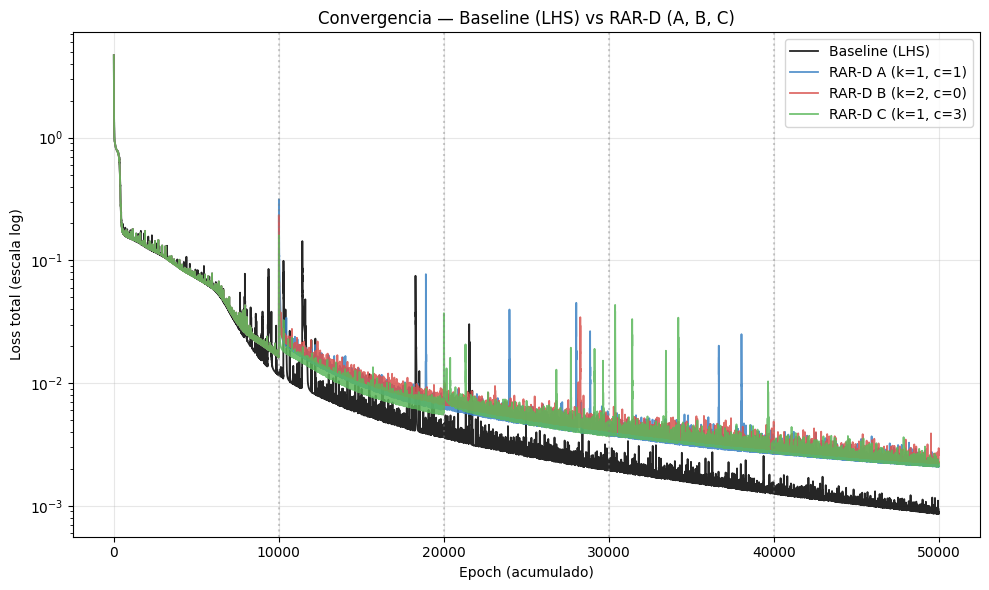

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'baseline': 'black', 'A': '#3B82C4', 'B': '#D9534F', 'C': '#5CB85C'}

for key, res in results.items():
    ax.plot(res['history']['total'], label=res['name'], color=colors[key], linewidth=1.3, alpha=0.85)

# Límites de ronda para las corridas RAR-D (todas comparten el mismo esquema de épocas)
for i in range(1, N_ROUNDS + 1):
    ax.axvline(i * EPOCHS_PER_BLOCK, color='gray', linestyle=':', alpha=0.4)

ax.set_yscale('log')
ax.set_xlabel('Epoch (acumulado)')
ax.set_ylabel('Loss total (escala log)')
ax.set_title('Convergencia — Baseline (LHS) vs RAR-D (A, B, C)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_tp2_convergencia.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.4 Visualización de la evolución del muestreo adaptativo (RAR-D)

Se grafican, para cada configuración, el conjunto inicial de puntos LHS junto con los puntos agregados en
cada ronda (coloreados por ronda), para ver visualmente **dónde** RAR-D decide refinar el muestreo.

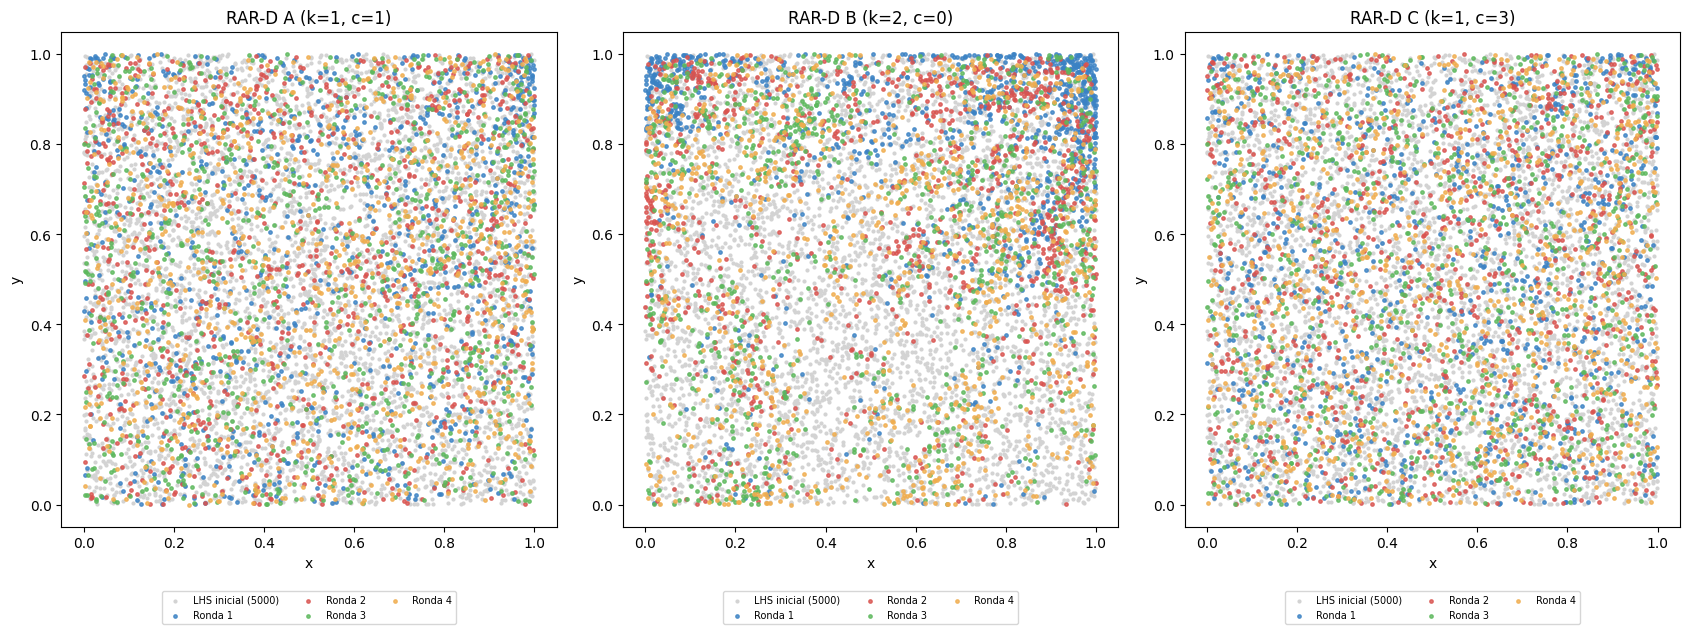

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
round_colors = ['#3B82C4', '#D9534F', '#5CB85C', '#F0AD4E', '#9B59B6']

for ax, key in zip(axes, ['A', 'B', 'C']):
    res = results[key]
    x_all, y_all = res['x_pde_final'], res['y_pde_final']
    n_init = N_INIT_RAD
    ax.scatter(x_all[:n_init], y_all[:n_init], s=4, c='lightgray', label=f'LHS inicial ({n_init})')

    offset = n_init
    for r in range(1, N_ROUNDS + 1):
        n_this_round = N_ADD_PER_ROUND
        xs = x_all[offset:offset + n_this_round]
        ys = y_all[offset:offset + n_this_round]
        ax.scatter(xs, ys, s=6, c=round_colors[r - 1], label=f'Ronda {r}', alpha=0.8)
        offset += n_this_round

    ax.set_title(res['name'])
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.tight_layout()
plt.savefig('fig_tp2_muestreo_adaptativo.png', dpi=120, bbox_inches='tight')
plt.show()


### 4.5 Campos de error absoluto — mejor configuración vs baseline

Se comparan los campos de error absoluto de $u$ entre el baseline y la configuración que haya dado el menor
error relativo (se determina automáticamente a partir de la tabla de la sección 4.2).

Mejor configuración (según suma de errores relativos u+v+p): RAR-D C (k=1, c=3)


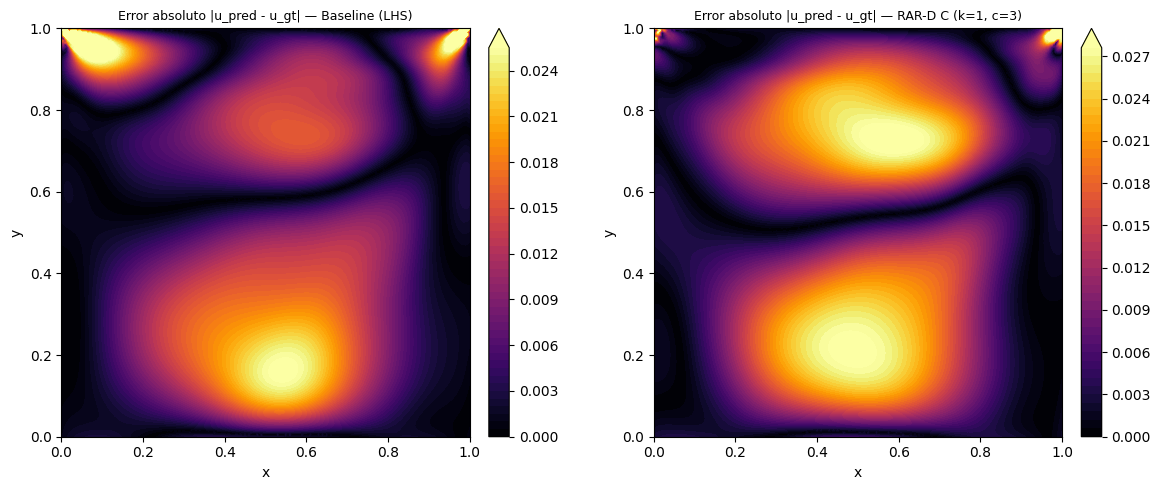

In [15]:
best_key = min(results, key=lambda k: results[k]['eval']['err_u_rel'] +
                                              results[k]['eval']['err_v_rel'] +
                                              results[k]['eval']['err_p_rel'])
print(f'Mejor configuración (según suma de errores relativos u+v+p): {results[best_key]["name"]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, key in zip(axes, ['baseline', best_key]):
    ev = results[key]['eval']
    err_u = np.abs(ev['u_pred'] - u_gt)
    vmax = np.percentile(err_u, 99)
    sc = ax.tricontourf(x_gt, y_gt, np.clip(err_u, 0, vmax), levels=51, cmap='inferno', extend='max')
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"Error absoluto |u_pred - u_gt| — {results[key]['name']}", fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig_tp2_error_comparacion.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. Discusión

**¿Cuál de todas las configuraciones alcanzó el mejor desempeño?**

Depende de qué variable se priorice.
En 𝑢 y 𝑣, el baseline LHS fue el más preciso (6.32% y 9.74% de error relativo respectivamente), y esto es consistente con su curva de convergencia (Fig. de convergencia), que alcanza un loss final visiblemente menor y más estable que las 3 configuraciones RAR-D.

En 𝑝, en cambio, las tres configuraciones RAR-D mejoraron notablemente al baseline (~31% vs 40.87%).

Si se prioriza el desempeño global (suma de errores relativos), RAR-D C (k=1, c=3) resulta la mejor, aunque vale aclarar que esto está dominado por su mejora en 𝑝: en el campo de error absoluto de 𝑢, RAR-D C en realidad tiene un pico de error mayor que el baseline (0.027 vs 0.024).

**¿Es consistente esta conclusión con lo que usted esperaba? ¿Por qué sí o por qué no?**

Parcialmente. Se esperaba que RAR-D superara al baseline en 𝑢 y
𝑣 al concentrar puntos en zonas de residuo alto de las ecuaciones de momento y continuidad y sin embargo el baseline fue más preciso ahí. Dos factores lo explican, visibles en los gráficos: (1) el esquema RAR-D termina con menos puntos de colocación en total (9.000 vs 10.000 fijos del baseline, por la discrepancia del enunciado documentada al inicio del notebook), y (2) la curva de convergencia muestra que cada ronda de RAR-D introduce inestabilidad (picos de loss) que interrumpe el progreso de optimización, mientras que el baseline entrena de forma continua sobre el mismo conjunto de puntos desde el epoch 1.

La mejora consistente en 𝑝 en las 3 configuraciones sí es un resultado más esperable: como el gradiente de presión aparece dentro de los residuos de momento, refinar el muestreo en zonas de alto residuo ayuda indirectamente a que la red aprenda mejor la estructura del campo de presión en todo el dominio.

**¿Cómo impacta la estrategia RAR-D en el costo computacional?**

En tiempo total fue prácticamente equivalente al baseline (23.6–23.9 min vs 23.7 min), pero el gráfico de muestreo adaptativo revela un costo "oculto" no reflejado en el tiempo: la necesidad de recalcular ε(x) sobre 20.000 puntos candidatos en cada una de las 4 rondas (8 pasadas de autodiferenciación de segundo orden extra en total), que se compensa porque durante gran parte del entrenamiento RAR-D trabaja con menos puntos de colocación que el baseline (arranca con 5.000 y llega a 9.000, vs 10.000 fijos).

In [16]:
df_ranked = df_summary.sort_values(by=['Error rel. u (%)', 'Error rel. v (%)', 'Error rel. p (%)'])
print('Ranking por error relativo de u (de menor a mayor):')
df_ranked


Ranking por error relativo de u (de menor a mayor):


,Configuración,N_pde final,Épocas totales,Tiempo entren. (min),Error rel. u (%),Error rel. v (%),Error rel. p (%)
0,Baseline (LHS),10000,50000,23.73,6.319,9.742,40.868
3,"RAR-D C (k=1, c=3)",9000,50000,23.83,7.114,10.122,30.961
1,"RAR-D A (k=1, c=1)",9000,50000,23.62,7.355,10.332,30.675
2,"RAR-D B (k=2, c=0)",9000,50000,23.92,7.633,10.907,30.977
